In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc

import rmm
import cupy
import cudf
import cupy as cp
import cvxpy as cpv
from rmm.allocators.cupy import rmm_cupy_allocator
from sklearn.feature_extraction.text import CountVectorizer
from cuml.linear_model import ElasticNet

import torch
from torchnmf.nmf import NMF

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 3

# Data Description

- `.X`: Filtered, normalized, and log-transformed count matrix.
- `.raw`: Original, filtered raw count matrix.
- `.obsm['MAGIC_imputed_data']`: Imputed count matrix using MAGIC algorithm.
- `.obsm['tsne']`: t-SNE maps (as presented in the manuscript), generated using scaled diffusion components.
- `.obs['clusters']`: Cell clustering information.
- `.obs['palantir_pseudotime']`: Cell pseudo-time ordering, as determined by Palantir.
- `.obs['palantir_diff_potential']`: Palantir-determined differentiation potential of cells.
- `.obsm['palantir_branch_probs']`: Probabilities of cells branching into different lineages, according to Palantir.
- `.uns['palantir_branch_probs_cell_types']`: Labels for Palantir branch probabilities.
- `.uns['ct_colors']`: Color codes for cell types, as used in the manuscript.
- `.uns['cluster_colors']`: Color codes for cell clusters, as used in the manuscript.


In [2]:
%%time
dir_path = "/nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/setty_2019/"

# Find all h5ad files in the directory
h5ad_files = glob.glob(os.path.join(dir_path, "*rep*.h5ad"))
print(f"Files: ")
for x in h5ad_files:
    print("\t - ", os.path.basename(x))

# Read each file into a list of AnnData objects
adatas = [sc.read_h5ad(f) for f in h5ad_files]

# Concatenate into a single AnnData object
adata = sc.concat(
    adatas, 
    join="outer", 
    label="batch", 
    keys=[os.path.basename(f) for f in h5ad_files],
)

adata.obs_names_make_unique()
adata

Files: 
	 -  human_cd34_bm_rep1.h5ad
	 -  human_cd34_bm_rep3.h5ad
	 -  human_cd34_bm_rep2.h5ad
CPU times: user 13.5 s, sys: 5.31 s, total: 18.8 s
Wall time: 19.1 s


/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 24327 × 15801
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential', 'batch'
    obsm: 'tsne', 'MAGIC_imputed_data', 'palantir_branch_probs'

# Merge metadata

In [3]:
%%time

# Path to metadata CSV
meta_csv = "/nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/setty_2019/HaematopoieticProfiling-10x_cell_type_2020-03-12.csv"

# Read metadata as DataFrame
meta = pd.read_csv(meta_csv)
print(f"Metadata shape: {meta.shape}")
print(f"adata.obs shape before merge: {adata.obs.shape}")

# Reset indices to ensure default integer indexing
adata.obs = adata.obs.reset_index(drop=True)
meta = meta.reset_index(drop=True)

meta['cell_type'] = meta['annotated_cell_identity.text'].copy()

# Concatenate column-wise
adata.obs = pd.concat([adata.obs, meta], axis=1)
print(f"adata.obs shape after merge: {adata.obs.shape}")

print("adata.obs columns:", adata.obs.columns.tolist())
print(adata.obs.head())


Metadata shape: (24327, 6)
adata.obs shape before merge: (24327, 4)
adata.obs shape after merge: (24327, 11)
adata.obs columns: ['clusters', 'palantir_pseudotime', 'palantir_diff_potential', 'batch', 'cell_suspension.biomaterial_core.biomaterial_id', 'cell_suspension.provenance.document_id', 'annotated_cell_identity.text', 'annotated_cell_identity.ontology', 'annotated_cell_identity.ontology_label', 'barcode', 'cell_type']
  clusters  palantir_pseudotime  palantir_diff_potential  \
0        2             0.528063                 0.294430   
1        0             0.071683                 1.418632   
2        3             0.748991                 0.279959   
3        3             0.712743                 0.296824   
4        4             0.514219                 1.250914   

                     batch cell_suspension.biomaterial_core.biomaterial_id  \
0  human_cd34_bm_rep1.h5ad                                HS_BM_P1_cells_1   
1  human_cd34_bm_rep1.h5ad                              

# Keep only Replicate 1

In [4]:
adata = adata[adata.obs['batch'] == 'human_cd34_bm_rep1.h5ad', :].copy()
adata

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 5780 × 15801
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential', 'batch', 'cell_suspension.biomaterial_core.biomaterial_id', 'cell_suspension.provenance.document_id', 'annotated_cell_identity.text', 'annotated_cell_identity.ontology', 'annotated_cell_identity.ontology_label', 'barcode', 'cell_type'
    obsm: 'tsne', 'MAGIC_imputed_data', 'palantir_branch_probs'

In [5]:
print(adata.obs['cell_type'].value_counts().to_string())

cell_type
monocyte progenitor                     1153
hematopoietic stem cell                 1118
erythroid progenitor                    1007
hematopoietic multipotent progenitor     984
myeloid progenitor                       666
common lymphoid progenitor               488
dendtritic progenitor                    303
megakaryocyte progenitor                  61


# Simple processing

In [6]:
# store processed counts and recover the raw counts
adata.layers['processed'] = adata.X.copy()
adata.X = adata.raw.X.copy()
adata.layers['raw_counts'] = adata.X.copy()
adata.to_df().head()

index,A1BG,A2M,A2ML1,A4GALT,AAAS,AACS,AADAT,AAED1,AAGAB,AAK1,...,ZSWIM8,ZUFSP,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [7]:
rsc.get.anndata_to_GPU(adata)
rsc.pp.filter_genes(adata, min_counts=10)
rsc.pp.filter_cells(adata, min_counts=500)
rsc.pp.normalize_total(adata, target_sum=1e4)
rsc.pp.log1p(adata)
adata.layers['log_norm'] = adata.X.copy()
adata

filtered out 2137 genes that are detected in less than 10 counts


AnnData object with n_obs × n_vars = 5780 × 13664
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential', 'batch', 'cell_suspension.biomaterial_core.biomaterial_id', 'cell_suspension.provenance.document_id', 'annotated_cell_identity.text', 'annotated_cell_identity.ontology', 'annotated_cell_identity.ontology_label', 'barcode', 'cell_type', 'n_counts', 'n_genes'
    var: 'n_counts', 'n_cells'
    uns: 'log1p'
    obsm: 'tsne', 'MAGIC_imputed_data', 'palantir_branch_probs'
    layers: 'processed', 'raw_counts', 'log_norm'

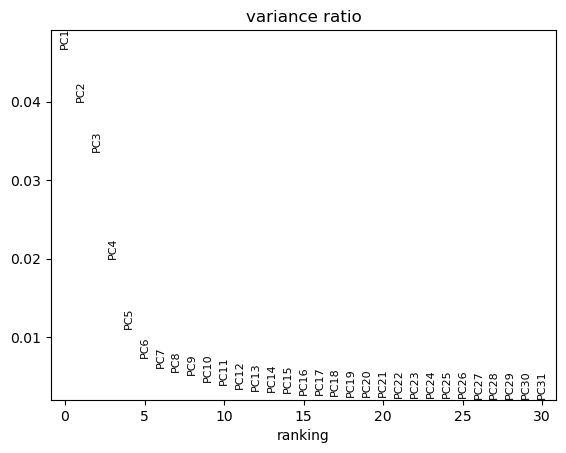

[2025-06-11 09:47:33.509] [CUML] [debug] n_neighbors=15
[2025-06-11 09:47:33.509] [CUML] [debug] Calling knn graph run
[2025-06-11 09:47:33.509] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-06-11 09:47:33.665] [CUML] [debug] Done. Calling remove zeros


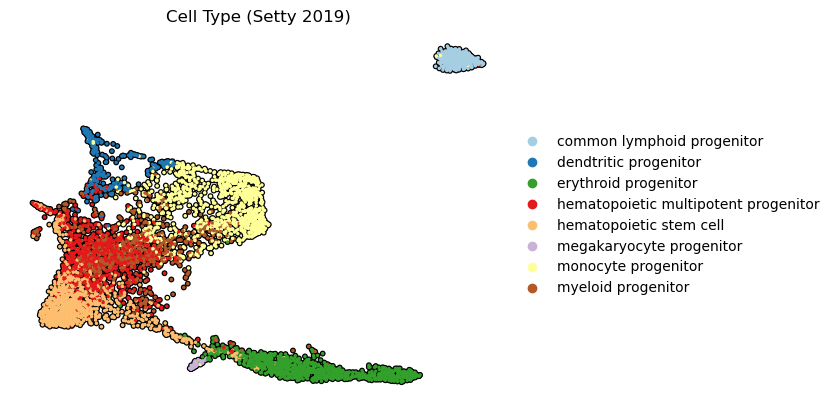

In [8]:
rsc.pp.highly_variable_genes(adata)
rsc.pp.pca(adata)
sc.pl.pca_variance_ratio(adata)

rsc.pp.neighbors(adata)
rsc.tl.umap(adata, min_dist=0.2)
sc.pl.umap(
    adata,
    color=['cell_type'],
    size=25,
    alpha=1,
    use_raw=False,
    add_outline=True,
    na_in_legend=False,
    palette='Paired',
    outline_color=('k', 'k'),
    title='Cell Type (Setty 2019)',
    frameon=False,
    wspace=0.25,
)

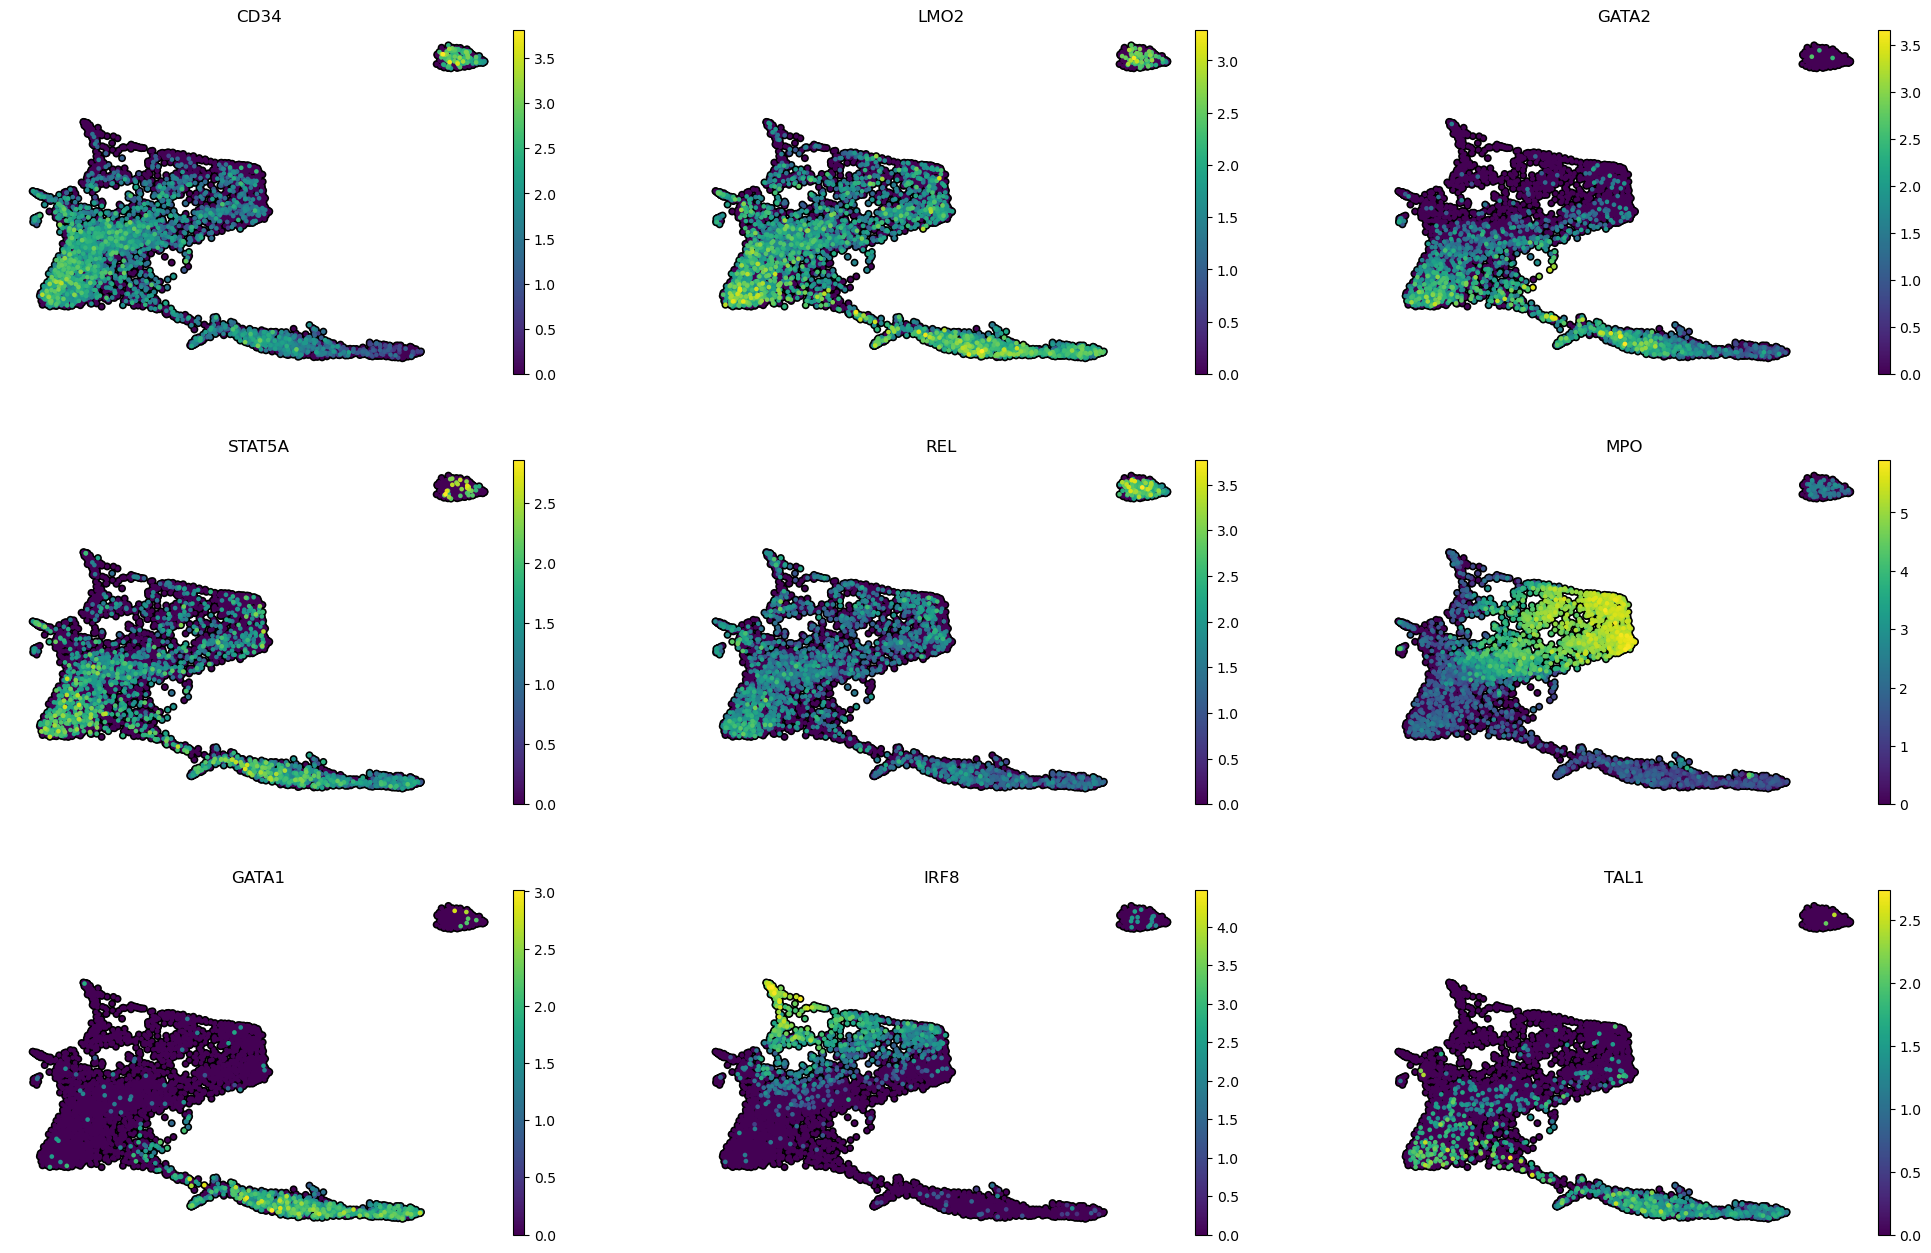

In [9]:
rsc.get.anndata_to_CPU(adata)

sc.pl.umap(
    adata,
    color=['CD34', 'LMO2', 'GATA2', 'STAT5A', 'REL', 'MPO', 'GATA1', 'IRF8', 'TAL1'],
    size=45,
    alpha=1,
    ncols=3,
    use_raw=False,
    add_outline=True,
    na_in_legend=False,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.25,
)

# Save Data

In [10]:
%%time
outpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/setty_2019/anndata.h5ad"
adata.write(outpath)
adata

CPU times: user 189 ms, sys: 673 ms, total: 861 ms
Wall time: 5.79 s


AnnData object with n_obs × n_vars = 5780 × 13664
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential', 'batch', 'cell_suspension.biomaterial_core.biomaterial_id', 'cell_suspension.provenance.document_id', 'annotated_cell_identity.text', 'annotated_cell_identity.ontology', 'annotated_cell_identity.ontology_label', 'barcode', 'cell_type', 'n_counts', 'n_genes'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'cell_type_colors'
    obsm: 'tsne', 'MAGIC_imputed_data', 'palantir_branch_probs', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'processed', 'raw_counts', 'log_norm'
    obsp: 'distances', 'connectivities'

In [11]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

# Archive

In [ ]:
download_url = "https://dp-lab-data-public.s3.amazonaws.com/palantir/marrow_sample_scseq_counts.h5ad"
file_path = os.path.join("./", "marrow_sample_scseq_counts.h5ad")
adata = sc.read(file_path, backup_url=download_url)

outpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/setty_2019/"
outfile = os.path.join(outpath, "marrow_sample_scseq_counts.h5ad")

# Save the AnnData object
adata.write(outfile)
adata

In [ ]:
adata.obs_names[:10]